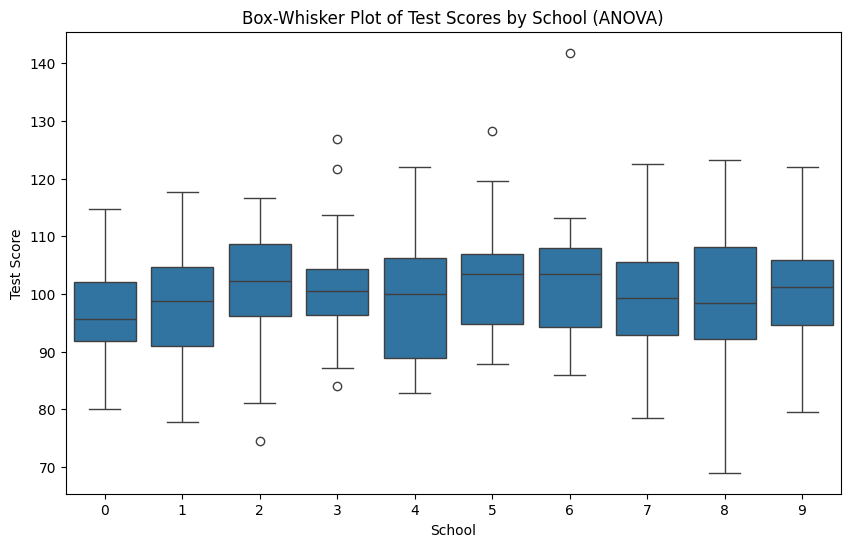

ANOVA Results:
                  sum_sq     df         F    PR(>F)
C(school)   1335.959914    9.0  1.489562  0.151084
Residual   28899.496522  290.0       NaN       NaN
Mixed Linear Model Summary:
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: score    
No. Observations: 300     Method:             REML     
No. Groups:       10      Scale:              0.9521   
Min. group size:  30      Log-Likelihood:     -440.5477
Max. group size:  30      Converged:          Yes      
Mean group size:  30.0                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept   50.031    0.533  93.929 0.000 48.987 51.075
study_hours  5.017    0.029 173.428 0.000  4.960  5.074
Group Var    1.970    0.982                            



/tmp/ipython-input-2317784252.py:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  re = mlm_model.random_effects[school][0]  # since it's just (1|school)


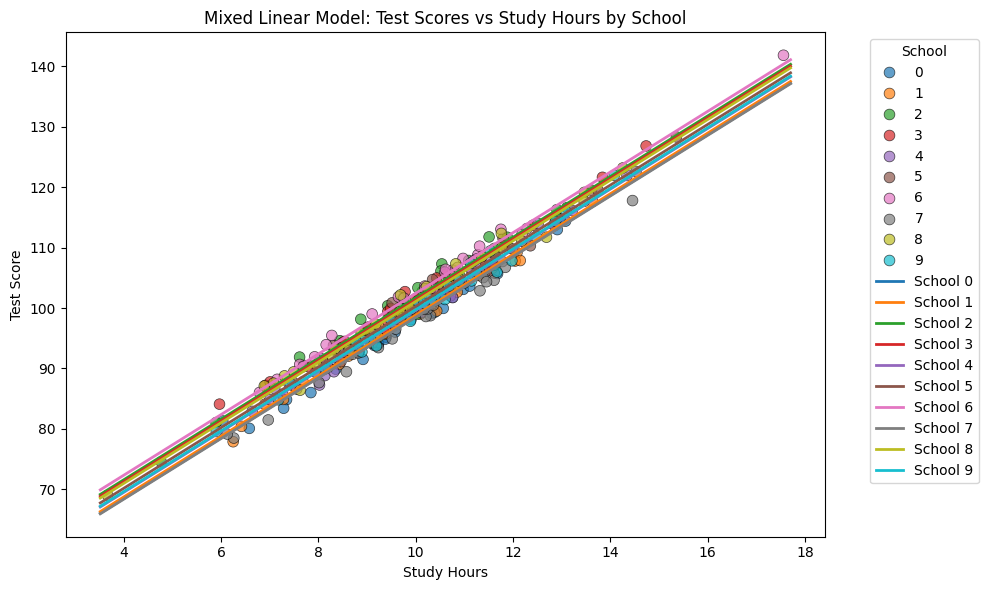

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Simulate Data
np.random.seed(42)

# Parameters
n_schools = 10
students_per_school = 30
n_students = n_schools * students_per_school

# Generate data
schools = np.repeat(np.arange(n_schools), students_per_school)
study_hours = np.random.normal(10, 2, n_students)
school_effect = np.random.normal(0, 2, n_schools)
individual_effect = np.random.normal(0, 1, n_students)
scores = 50 + 5 * study_hours + school_effect[schools] + individual_effect

# Create DataFrame
data = pd.DataFrame({
    'school': schools,
    'study_hours': study_hours,
    'score': scores
})

# Boxplot for ANOVA
plt.figure(figsize=(10, 6))
sns.boxplot(x='school', y='score', data=data)
plt.title('Box-Whisker Plot of Test Scores by School (ANOVA)')
plt.xlabel('School')
plt.ylabel('Test Score')
plt.show()

# Perform One-Way ANOVA
anova_model = smf.ols('score ~ C(school)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("ANOVA Results:\n", anova_table)

# Mixed Linear Model (MLM)
# Model: Test Score ~ Study Hours + (1|School) (Random Intercept Model)
mlm_model = smf.mixedlm("score ~ study_hours", data, groups=data['school']).fit()
print("Mixed Linear Model Summary:\n", mlm_model.summary())


# --- Scatter Plot of Study Hours vs Test Scores with MLM Regression Lines per School ---
plt.figure(figsize=(10, 6))

# Add x-jitter to reduce overlap among categories
jitter_strength = 0.2
x_jittered = data['study_hours'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(data))

sns.scatterplot(
    x=x_jittered,
    y='score',
    hue='school',
    data=data,
    palette='tab10',
    alpha=0.7,
    s=60,
    edgecolor='k',
    linewidth=0.5
)

# Draw fitted lines (ŷ) for each school
x_seq = np.linspace(data['study_hours'].min(), data['study_hours'].max(), 100)
schools = sorted(data['school'].unique())

for school in schools:
    # Extract random intercept for this school (scalar)
    re = mlm_model.random_effects[school][0]  # since it's just (1|school)
    intercept = mlm_model.fe_params['Intercept'] + re
    slope = mlm_model.fe_params['study_hours']
    y_hat = intercept + slope * x_seq
    plt.plot(x_seq, y_hat, lw=2, label=f"School {school}")

plt.title('Mixed Linear Model: Test Scores vs Study Hours by School')
plt.xlabel('Study Hours')
plt.ylabel('Test Score')
plt.legend(title="School", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The differences in this data cloud is not very obvious- lets try to make it more obvious by increasing the variability levels between groups...

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    score    
No. Observations:      300        Method:                REML     
No. Groups:            10         Scale:                 3.8107   
Min. group size:       30         Log-Likelihood:        -672.1328
Max. group size:       30         Converged:             Yes      
Mean group size:       30.0                                       
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               44.405    2.494 17.806 0.000 39.517 49.293
study_hours              3.815    0.356 10.720 0.000  3.118  4.513
Group Var               58.040   15.056                           
Group x study_hours Cov -1.026    1.524                           
study_hours Var          1.227    0.311                           



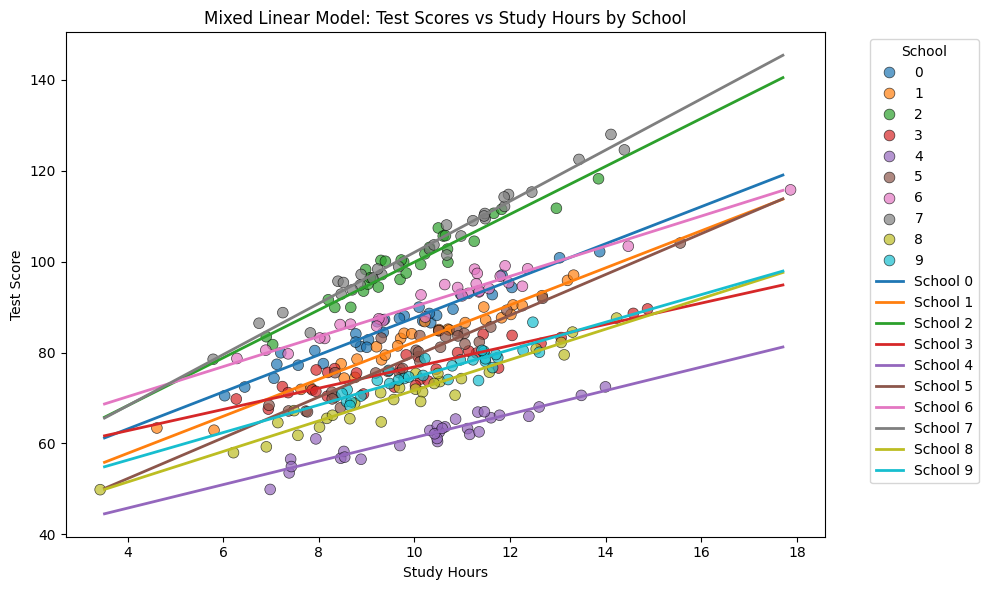

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Simulate Data with Stronger Between-School Differences ---
np.random.seed(42)

n_schools = 10
students_per_school = 30
n_students = n_schools * students_per_school

schools = np.repeat(np.arange(n_schools), students_per_school)

# Stronger random intercepts and slopes for schools
school_intercepts = np.random.normal(0, 10, n_schools)   # larger spread (was 2)
school_slopes = np.random.normal(5, 1.5, n_schools)      # each school has its own slope

study_hours = np.random.normal(10, 2, n_students)
individual_effect = np.random.normal(0, 2, n_students)

scores = (
    40
    + school_intercepts[schools]
    + school_slopes[schools] * study_hours
    + individual_effect
)

data = pd.DataFrame({
    'school': schools,
    'study_hours': study_hours,
    'score': scores
})

# --- Fit Mixed Linear Model (Random Intercept + Slope) ---
mlm_model = smf.mixedlm(
    "score ~ study_hours",
    data,
    groups=data["school"],
    re_formula="~study_hours"
).fit()
print(mlm_model.summary())

# --- Plot Scatter + Fitted Lines per School ---
plt.figure(figsize=(10, 6))

# Add jitter for visibility
jitter_strength = 0.25
x_jittered = data["study_hours"] + np.random.uniform(-jitter_strength, jitter_strength, size=len(data))

sns.scatterplot(
    x=x_jittered,
    y="score",
    hue="school",
    data=data,
    palette="tab10",
    alpha=0.7,
    s=60,
    edgecolor="k",
    linewidth=0.5
)

# Generate regression lines for each school
x_seq = np.linspace(data["study_hours"].min(), data["study_hours"].max(), 100)

for school in sorted(data["school"].unique()):
    re = mlm_model.random_effects[school]
    intercept = mlm_model.fe_params["Intercept"] + re["Group"] # Use 'Group' for random intercept
    slope = mlm_model.fe_params["study_hours"] + re["study_hours"]
    y_hat = intercept + slope * x_seq
    plt.plot(x_seq, y_hat, lw=2, label=f"School {school}")

plt.title("Mixed Linear Model: Test Scores vs Study Hours by School")
plt.xlabel("Study Hours")
plt.ylabel("Test Score")
plt.legend(title="School", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

This graph and model fit clearly shows that **there are clear-observable differences between the test scores of students from across the selected set of schools**

We now need to **quantify** how exactly are they different with values and their significances.

We will do this with applying two models:
1. ANOVA
2. Mixed Liear Model Regression

For practical purposes- we will revert back to the original settings for generating the simulated data...

<Figure size 1200x600 with 0 Axes>

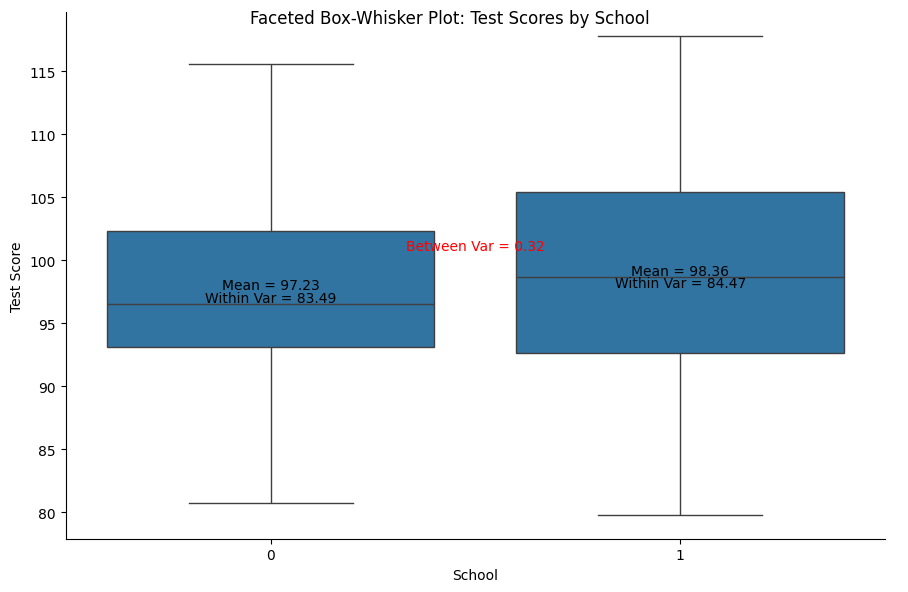

ANOVA Results:
                 sum_sq    df         F    PR(>F)
C(school)    19.037870   1.0  0.226695  0.635774
Residual   4870.838009  58.0       NaN       NaN
Mixed Linear Model Summary:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: score   
No. Observations: 60      Method:             REML    
No. Groups:       2       Scale:              0.9356  
Min. group size:  30      Log-Likelihood:     -85.6621
Max. group size:  30      Converged:          Yes     
Mean group size:  30.0                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept   49.555    0.710 69.752 0.000 48.163 50.948
study_hours  4.978    0.069 71.761 0.000  4.842  5.114
Group Var    0.075    0.156                           



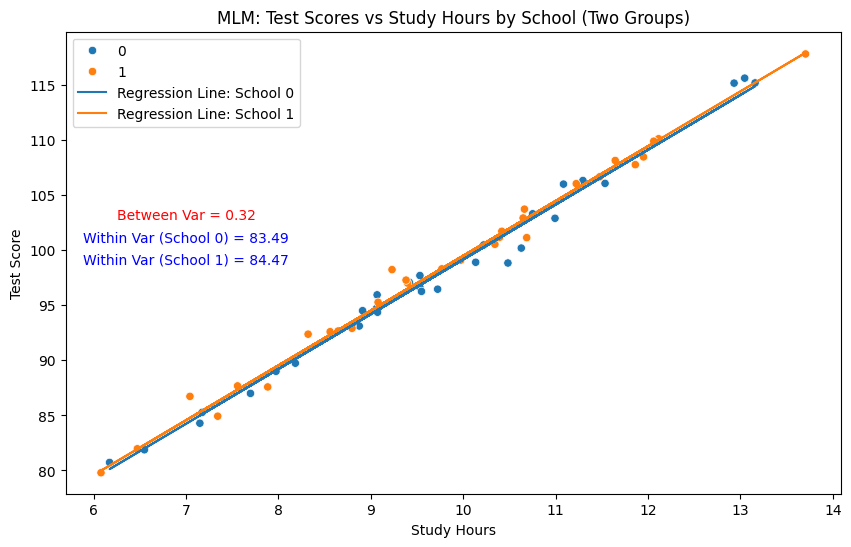

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Simulate Data for 2 Schools
np.random.seed(42)

# Parameters
n_schools = 2
students_per_school = 30
n_students = n_schools * students_per_school

# Generate data
schools = np.repeat(np.arange(n_schools), students_per_school)
study_hours = np.random.normal(10, 2, n_students)
school_effect = np.random.normal(0, 2, n_schools)
individual_effect = np.random.normal(0, 1, n_students)
scores = 50 + 5 * study_hours + school_effect[schools] + individual_effect

# Create DataFrame for 2 schools
data = pd.DataFrame({
    'school': schools,
    'study_hours': study_hours,
    'score': scores
})


#------Step 0 -- Exploratory Data Analysis & Visualization -----

# Faceted Box-Whisker Plot
plt.figure(figsize=(12, 6))
g = sns.catplot(x='school', y='score', data=data, kind='box', height=6, aspect=1.5)
g.set_axis_labels("School", "Test Score")
plt.suptitle("Faceted Box-Whisker Plot: Test Scores by School")

# Calculate and annotate group means and variance components
group_means = data.groupby('school')['score'].mean()
overall_mean = data['score'].mean()
within_variances = data.groupby('school')['score'].var()
between_variance = np.var(group_means)

# Annotating group means and variances on the plot
for i, (school, mean) in enumerate(group_means.items()):
    plt.text(i, mean + 0.5, f'Mean = {mean:.2f}', horizontalalignment='center', size='medium', color='black')
    plt.text(i, mean - 0.5, f'Within Var = {within_variances[school]:.2f}', horizontalalignment='center', size='medium', color='black')

plt.text(0.5, overall_mean + 3, f'Between Var = {between_variance:.2f}', horizontalalignment='center', size='medium', color='red')
plt.show()

#----Step 1 -- Hypothesis Testing with ANOVA : Is there are significance difference between the data from any of the schools?
# Perform One-Way ANOVA

anova_model = smf.ols('score ~ C(school)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("ANOVA Results:\n", anova_table)

#---Step 2 -- Hypothesis Testing with Mixed Linear Model -
## Assumption: the schools listed here are a *random* subset of all possible schools we should have sampled

# Mixed Linear Model (MLM) with Two Schools
mlm_model = smf.mixedlm("score ~ study_hours", data, groups=data['school']).fit()
print("Mixed Linear Model Summary:\n", mlm_model.summary())

#--Step 3 -- Vizualization & Results
# Scatter Plot of Study Hours vs Test Scores with MLM Regression Lines for Two Schools
plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='score', data=data, hue='school', palette='tab10')

# Plot the regression line from MLM for each school
for school in range(n_schools):
    school_data = data[data['school'] == school]
    plt.plot(school_data['study_hours'], mlm_model.fittedvalues[school_data.index], label=f'Regression Line: School {school}')



# Annotate variance components on the plot
overall_mean = data['score'].mean()
plt.text(7, overall_mean + 5, f'Between Var = {between_variance:.2f}', horizontalalignment='center', size='medium', color='red')
plt.text(7, overall_mean + 3, f'Within Var (School 0) = {within_variances[0]:.2f}', horizontalalignment='center', size='medium', color='blue')
plt.text(7, overall_mean + 1, f'Within Var (School 1) = {within_variances[1]:.2f}', horizontalalignment='center', size='medium', color='blue')

plt.title('MLM: Test Scores vs Study Hours by School (Two Groups)')
plt.xlabel('Study Hours')
plt.ylabel('Test Score')
plt.legend()
plt.show()


These graphs are OK- but lets use a different library that provides interactive visualizations `plotly`

Since this is only for demonstration purposes- we will only simulate data from 4 schools instead of the initial 10

In [ ]:
!pip install plotly statsmodels pandas numpy


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Simulate Data for 4 Schools
np.random.seed(42)

# Parameters
n_schools = 4
students_per_school = 30
n_students = n_schools * students_per_school

# Generate data
schools = np.repeat(np.arange(n_schools), students_per_school)
study_hours = np.random.normal(10, 2, n_students)
school_effect = np.random.normal(0, 2, n_schools)
individual_effect = np.random.normal(0, 1, n_students)
scores = 50 + 5 * study_hours + school_effect[schools] + individual_effect

# Create DataFrame for 4 schools
data = pd.DataFrame({
    'school': schools,
    'study_hours': study_hours,
    'score': scores
})

# ANOVA Box-Whisker Plot using Plotly
fig_anova = px.box(data, x='school', y='score', title='Box-Whisker Plot: Test Scores by School (ANOVA)',
                   #facet_col='school',
                   color='school',labels={"school": "School", "score": "Test Score"})

# Calculate and annotate group means and variance components
group_means = data.groupby('school')['score'].mean()
within_variances = data.groupby('school')['score'].var()
overall_mean = data['score'].mean()
between_variance = np.var(group_means)

# Adding annotations for means and variances
for school in range(n_schools):
    fig_anova.add_annotation(x=school, y=group_means[school] + 2,
                             text=f"Mean = {group_means[school]:.2f}<br>Within Var = {within_variances[school]:.2f}",
                             showarrow=False, font=dict(color='black'))

fig_anova.add_annotation(x=1.5, y=overall_mean + 10, text=f"Between Var = {between_variance:.2f}",
                         showarrow=False, font=dict(color='red'))

fig_anova.show()

# Perform One-Way ANOVA
anova_model = smf.ols('score ~ C(school)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("ANOVA Results:\n", anova_table)

# Mixed Linear Model (MLM) with 4 Schools
mlm_model = smf.mixedlm("score ~ study_hours", data, groups=data['school']).fit()
print("Mixed Linear Model Summary:\n", mlm_model.summary())

# Scatter Plot of Study Hours vs Test Scores with MLM Regression Lines for 4 Schools using Plotly
fig_mlm = px.scatter(data, x='study_hours', y='score', color='school', title='MLM: Test Scores vs Study Hours by School',
                     #facet_col='school',
                    labels={"study_hours": "Study Hours", "score": "Test Score"})

# Adding MLM regression lines and annotations
for school in range(n_schools):
    school_data = data[data['school'] == school]
    fig_mlm


ANOVA Results:
                  sum_sq     df         F    PR(>F)
C(school)    740.607643    3.0  2.852039  0.040374
Residual   10040.826796  116.0       NaN       NaN
Mixed Linear Model Summary:
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: score    
No. Observations: 120     Method:             REML     
No. Groups:       4       Scale:              0.9970   
Min. group size:  30      Log-Likelihood:     -180.7406
Max. group size:  30      Converged:          Yes      
Mean group size:  30.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    50.475    1.436 35.154 0.000 47.661 53.289
study_hours   4.954    0.050 99.780 0.000  4.857  5.051
Group Var     7.258    6.035                           



Compare and contrast the ANOVA results with MLM results.

  - What is different?
  - What is the same?

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.formula.api as smf

# --- Simulate Data for 4 Schools ---
np.random.seed(42)

n_schools = 4
students_per_school = 30
n_students = n_schools * students_per_school

schools = np.repeat(np.arange(n_schools), students_per_school)
study_hours = np.random.normal(10, 2, n_students)
school_effect = np.random.normal(0, 2, n_schools)
individual_effect = np.random.normal(0, 1, n_students)
scores = 50 + 5 * study_hours + school_effect[schools] + individual_effect

data = pd.DataFrame({
    "school": schools,
    "study_hours": study_hours,
    "score": scores
})

# --- Fit Mixed Linear Model ---
mlm_model = smf.mixedlm("score ~ study_hours", data, groups=data["school"]).fit()

# --- Subplots: 2 rows, 5 columns ---
fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=["School 0", "School 1", "School 2", "School 3", "Total Distribution"],
    row_heights=[0.5, 0.5],
    vertical_spacing=0.1
)

# --- Row 1: Boxplots ---
for school in range(n_schools):
    fig.add_trace(
        go.Box(
            y=data.loc[data["school"] == school, "score"],
            name=f"School {school}",
            boxmean=True,
            marker_color="blue"
        ),
        row=1, col=school + 1
    )

fig.add_trace(
    go.Box(
        y=data["score"],
        name="Total",
        boxmean=True,
        marker_color="green"
    ),
    row=1, col=5
)

# --- Row 2: Scatter + Regression Lines ---
x_seq = np.linspace(data["study_hours"].min(), data["study_hours"].max(), 100)
beta0 = mlm_model.fe_params["Intercept"]
beta1 = mlm_model.fe_params["study_hours"]

for school in range(n_schools):
    school_data = data[data["school"] == school]
    re = mlm_model.random_effects[school].iloc[0]  # random intercept

    # Compute fitted line explicitly
    intercept = beta0 + re
    y_hat = intercept + beta1 * x_seq

    # Scatter
    fig.add_trace(
        go.Scatter(
            x=school_data["study_hours"],
            y=school_data["score"],
            mode="markers",
            name=f"School {school}",
            marker=dict(size=6)
        ),
        row=2, col=school + 1
    )

    # Regression line fit
    fig.add_trace(
        go.Scatter(
            x=x_seq,
            y=y_hat,
            mode="lines",
            line=dict(color="red", width=2),
            showlegend=False
        ),
        row=2, col=school + 1
    )

# --- Total Panel (All Schools Combined) ---
fig.add_trace(
    go.Scatter(
        x=data["study_hours"],
        y=data["score"],
        mode="markers",
        name="Total",
        marker_color="green"
    ),
    row=2, col=5
)

# Population-level line (fixed effects only)
y_total_hat = beta0 + beta1 * x_seq
fig.add_trace(
    go.Scatter(
        x=x_seq,
        y=y_total_hat,
        mode="lines",
        line=dict(color="black", width=3, dash="dash"),
        name="Population-level Fit",
        showlegend=False
    ),
    row=2, col=5
)

# --- Layout ---
fig.update_layout(
    height=700,
    width=1200,
    title_text="ANOVA & Mixed Linear Model Comparison (4 Schools)",
    showlegend=False
)

fig.update_xaxes(title_text="Study Hours", row=2, col=3)
fig.update_yaxes(title_text="Test Score", row=2, col=1)

fig.show()


The visuals are quite descriptive.

In an ANOVA framework-we are simply **comparing two distributions** with each other based on the parameters of the distribution- that are simply the mean and the variance, while in the MLM frame work- we are fitting a conditional-regression model to the data- where each school represents an random sample for the assesment of **relationship between the test scores of individuals conditional on the school they attend**.

 - What are the parameters $\beta_0$ and $\beta_1$ for each of the fitted models per school from MLM?

 - How can we evaluate if any of these schools produced a score distribution that is significantly different then the others?

 - Are any of these schools show any indicators of being an "out-of-distribution" sample?